The boundary conditions are initialized with arrays 
 [[ 0.         -0.         -0.         -0.         -0.         -0.
   0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.31286893]
 [ 0.          0.          0.          0.          0.          0.
   0.907981  ]
 [ 0.          0.          0.          0.          0.          0.
   1.41421356]
 [ 0.          0.          0.          0.          0.          0.
   1.78201305]
 [ 0.          0.          0.          0.          0.          0.
   1.97537668]
 [ 0.          0.          0.          0.          0.          0.
   1.97537668]
 [ 0.          0.          0.          0.          0.          0.
   1.78201305]
 [ 0.          0.          0.          0.          0.          0.
   1.41421356]
 [ 0.          0.          0.          0.          0.          0.
   0.907981  ]
 [ 0.          0.          0.          0.          0.          0.
   0.31286893]
 [ 0.         -0.         -0.         -0.         -0.  

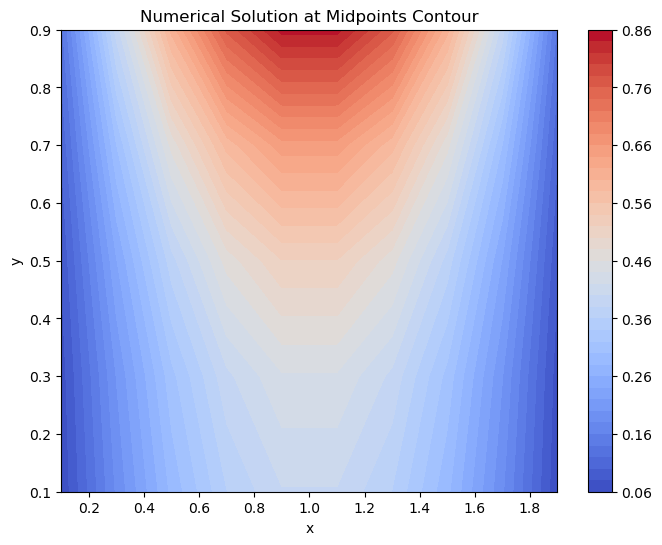

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Lx, Ly = 2.0, 1.0
nx, ny = 10,5
dx, dy = Lx / nx, Ly / ny
tolerance = 1e-7

# Initialize temperature array including ghost cells
T = np.zeros((nx + 2, ny + 2))

# Function to set boundary conditions
def set_boundary_conditions(T, nx, ny, dx, dy):
    for i in range(1, nx + 1):  # Top boundary (y = 1)
        x = (i - 0.5) * dx
        T[i, ny + 1] = 2 * np.sin(np.pi * x / 2) - T[i, ny]

    for i in range(1, nx + 1):  # Bottom boundary (y = 0)
        T[i, 0] = T[i, 1]

    for j in range(1, ny + 1):  # Left boundary (x = 0)
        T[0, j] = -T[1, j]

    for j in range(1, ny + 1):  # Right boundary (x = Lx)
        T[nx + 1, j] = -T[nx, j]

    return T
print(f"The boundary conditions are initialized with arrays \n {set_boundary_conditions(T, nx, ny, dx, dy)}")

# Gauss-Seidel iteration function
def gauss_seidel_iteration(T, nx, ny):
    for i in range(1, nx + 1):
        for j in range(1, ny + 1):
            T[i, j] = 0.25 * (T[i+1, j] + T[i-1, j] + T[i, j+1] + T[i, j-1])
    return T

# L2 norm calculation
def L2_normalization(T, old_T, nx, ny):
    diff = T[1:nx+1, 1:ny+1] - old_T[1:nx+1, 1:ny+1]
    return np.sqrt(np.sum(diff**2)/(nx*ny))


# Apply boundary conditions
T = set_boundary_conditions(T, nx, ny, dx, dy)

# Iterative solution with Gauss-Seidel
iteration = 0
L2_norm = 1e10
while L2_norm > tolerance:
    old_T = T.copy()
    T = gauss_seidel_iteration(T, nx, ny)
    T = set_boundary_conditions(T, nx, ny, dx, dy)  # Reapply boundary conditions
    L2_norm = L2_normalization(T, old_T, nx, ny)
    iteration += 1
print(f"Solution converged after {iteration} number of iterations")
print(f"The Value of the L2 norm is {L2_norm}")


# Plotting function
def plot_solution_midpoints(T, nx, ny, dx, dy):
    x = np.linspace(dx / 2, Lx - dx / 2, nx)  # Midpoints along x
    y = np.linspace(dy / 2, Ly - dy / 2, ny)  # Midpoints along y
    X, Y = np.meshgrid(x, y)

    # Extract the interior points (excluding ghost cells)
    T_midpoints = T[1:nx + 1, 1:ny + 1]

    plt.figure(figsize=(8, 6))
    contour = plt.contourf(X, Y, T_midpoints.T, levels=50, cmap='coolwarm') 
    plt.colorbar(contour)  # Add color bar
    plt.title("Numerical Solution at Midpoints Contour")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

plot_solution_midpoints(T, nx, ny, dx, dy)

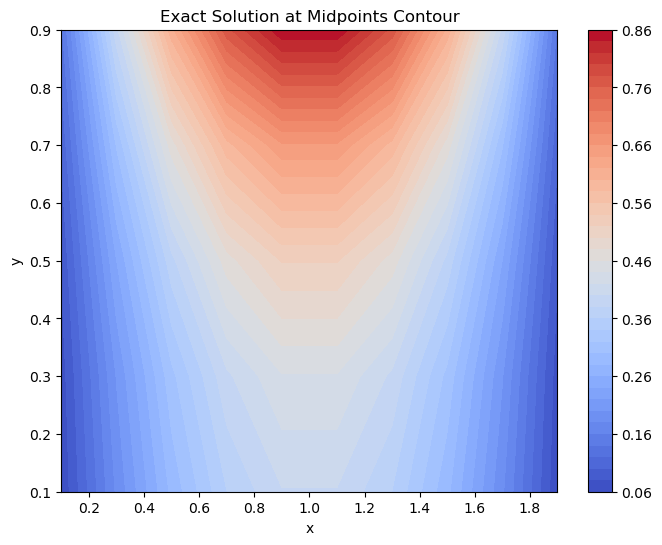

In [ ]:
# Parameters for the grid
Lx, Ly = 2.0, 1.0
nx, ny = 10, 5
dx, dy = Lx / nx, Ly / ny

# Function to compute the exact solution at cell centers
def exact_solution(nx, ny, dx, dy):
    T_exact = np.zeros((nx + 2, ny + 2))
    for i in range(1, nx + 1):
        for j in range(1, ny + 1):
            x = (i - 0.5) * dx
            y = (j - 0.5) * dy
            T_exact[i, j] = (np.sin(np.pi * x / 2) *
                             np.cosh(np.pi * y / 2) /
                             np.cosh(np.pi / 2))
    return T_exact

# Compute the exact solution
T_exact = exact_solution(nx, ny, dx, dy)

def plot_exact_solution_midpoints(T, nx, ny, dx, dy):
    x = np.linspace(dx / 2, Lx - dx / 2, nx)  # Midpoints along x
    y = np.linspace(dy / 2, Ly - dy / 2, ny)  # Midpoints along y
    X, Y = np.meshgrid(x, y)

    # Extract the interior points (excluding ghost cells)
    T_midpoints = T[1:nx + 1, 1:ny + 1]

    plt.figure(figsize=(8, 6))
    contour = plt.contourf(X, Y, T_midpoints.T, levels=50, cmap='coolwarm') 
    plt.colorbar(contour)  # Add color bar
    plt.title("Exact Solution at Midpoints Contour")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

plot_exact_solution_midpoints(T_exact, nx, ny, dx, dy)

## L2 Norm Error

In [10]:
def L2_Norm_Error(T,T_exact):
    diff = T[1:nx+1, 1:ny+1] - T_exact[1:nx+1, 1:ny+1]
    # Calculate the L2 norm error
    L2_norm_error = np.sqrt(np.sum(diff**2) / (nx * ny))
    return L2_norm_error
L2_Norm_Error(T,T_exact)

np.float64(0.0033922296114047507)

In [6]:
print(f"The values of the temperature at cell centers calculated numerically: \n {T}")
print(f"The values of the temperature at cell centers calculated with the exact solution: \n {T_exact}")

The values of the temperature at cell centers calculated numerically: 
 [[ 0.         -0.06307772 -0.06925232 -0.08220587 -0.10320633 -0.13430938
   0.        ]
 [ 0.06307772  0.06307772  0.06925232  0.08220587  0.10320633  0.13430938
   0.17855955]
 [ 0.18305872  0.18305872  0.20097809  0.23857074  0.29951646  0.38978099
   0.51820001]
 [ 0.28512072  0.28512072  0.31303077  0.37158268  0.46650785  0.60709814
   0.80711542]
 [ 0.35927315  0.35927315  0.39444186  0.46822155  0.58783423  0.7649883
   1.01702475]
 [ 0.39825746  0.39825746  0.43724225  0.51902765  0.6516193   0.84799607
   1.12738061]
 [ 0.39825756  0.39825756  0.43724233  0.51902771  0.65161933  0.84799608
   1.1273806 ]
 [ 0.35927342  0.35927342  0.39444208  0.46822172  0.58783432  0.76498833
   1.01702472]
 [ 0.28512107  0.28512107  0.31303106  0.3715829   0.46650799  0.60709818
   0.80711538]
 [ 0.18305903  0.18305903  0.20097835  0.23857093  0.29951658  0.38978103
   0.51819997]
 [ 0.06307786  0.06307786  0.06925243  